# CosPlace thesis figures

CosPlace counterpart to `netvlad_thesis_figures.ipynb`. It evaluates all completed CSVs in `outputs/cosplace`, selects the best variant by Recall@1, and exports thesis-ready figures.

In [1]:
from __future__ import annotations

import csv
import importlib
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks': PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'thesis_figures' / 'cosplace'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATABASE_DIR = PROJECT_ROOT / 'datasets/dataset-2/frames-IMG_3609'
QUERY_DIR = PROJECT_ROOT / 'datasets/dataset-2/frames-IMG_3610'
DATABASE_LABELS_CSV = PROJECT_ROOT / 'datasets/dataset-2/labels/frames-IMG_3609.csv'
QUERY_LABELS_CSV = PROJECT_ROOT / 'datasets/dataset-2/labels/frames-IMG_3610.csv'
SIMILARITY_FILES = sorted((PROJECT_ROOT / 'outputs' / 'cosplace').glob('_cosplace_*_similarity.csv'))
TOP_K_VALUES = [1, 5, 10, 20]
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':10, 'axes.titleweight':'bold', 'axes.spines.top':False, 'axes.spines.right':False, 'figure.dpi':130})
print(f'Completed CosPlace variants: {len(SIMILARITY_FILES)}')
for path in SIMILARITY_FILES: print(' •', path.name)

Completed CosPlace variants: 5
 • _cosplace_resnet101_2048_similarity.csv
 • _cosplace_resnet152_2048_similarity.csv
 • _cosplace_resnet18_512_similarity.csv
 • _cosplace_resnet50_2048_similarity.csv
 • _cosplace_vgg16_512_similarity.csv


## Evaluate variants and select the strongest completed model

In [2]:
def load_labels(path):
    with path.open(newline='', encoding='utf-8') as handle:
        return {Path(row['image_path']).name: row['label'].strip().casefold() for row in csv.DictReader(handle)}

def pretty_name(path):
    return path.stem.removeprefix('_cosplace_').removesuffix('_similarity').replace('_', ' ')

database_paths = sorted(DATABASE_DIR.glob('*.jpg'))
query_paths = sorted(QUERY_DIR.glob('*.jpg'))
query_path_by_name = {path.name: path for path in query_paths}
database_label_by_name, query_label_by_name = load_labels(DATABASE_LABELS_CSV), load_labels(QUERY_LABELS_CSV)
database_labels = np.asarray([database_label_by_name[path.name] for path in database_paths], dtype=object)

def top_indices(scores, k):
    candidates = np.argpartition(scores, -k)[-k:]
    return candidates[np.argsort(-scores[candidates])]

def evaluate_file(path):
    totals = {k: 0 for k in TOP_K_VALUES}; count_by_label = Counter(); correct_by_label = Counter(); confusions = Counter(); examples = []; evaluated = 0
    with path.open(newline='', encoding='utf-8') as handle:
        reader = csv.reader(handle); header = next(reader)
        if len(header) - 2 != len(database_paths): raise ValueError(f'{path.name} does not match the current database ordering.')
        for row in reader:
            query_path = query_path_by_name.get(Path(row[1]).name)
            if query_path is None: raise FileNotFoundError(f'Query image from CSV is missing: {row[1]}')
            true_label = query_label_by_name.get(query_path.name)
            if true_label is None: continue
            scores = np.asarray(row[2:], dtype=np.float32); ranks = top_indices(np.nan_to_num(scores, nan=-np.inf), max(TOP_K_VALUES)); top5 = ranks[:5]
            predicted = int(ranks[0]); predicted_label = str(database_labels[predicted]); correct = predicted_label == true_label
            evaluated += 1; count_by_label[true_label] += 1; correct_by_label[true_label] += correct; confusions[(true_label, predicted_label)] += 1
            for k in TOP_K_VALUES: totals[k] += bool(np.any(database_labels[ranks[:k]] == true_label))
            examples.append({'query_index':int(row[0]), 'query_path':query_path, 'query_label':true_label, 'top5_indices':top5, 'top5_scores':scores[top5], 'top5_correct':database_labels[top5] == true_label})
    return {'recall':{k: totals[k] / evaluated for k in TOP_K_VALUES}, 'count_by_label':count_by_label, 'correct_by_label':correct_by_label, 'confusions':confusions, 'examples':examples}

if not SIMILARITY_FILES: raise FileNotFoundError('No CosPlace CSVs found in outputs/cosplace. Run notebooks/cosplace.ipynb first.')
evaluations = {path: evaluate_file(path) for path in SIMILARITY_FILES}
best_path = max(SIMILARITY_FILES, key=lambda path: evaluations[path]['recall'][1]); best = evaluations[best_path]
print(f"Best completed variant: {pretty_name(best_path)} — Recall@1 {best['recall'][1]:.1%}")

Best completed variant: resnet50 2048 — Recall@1 74.0%


## 1. Recall@K comparison

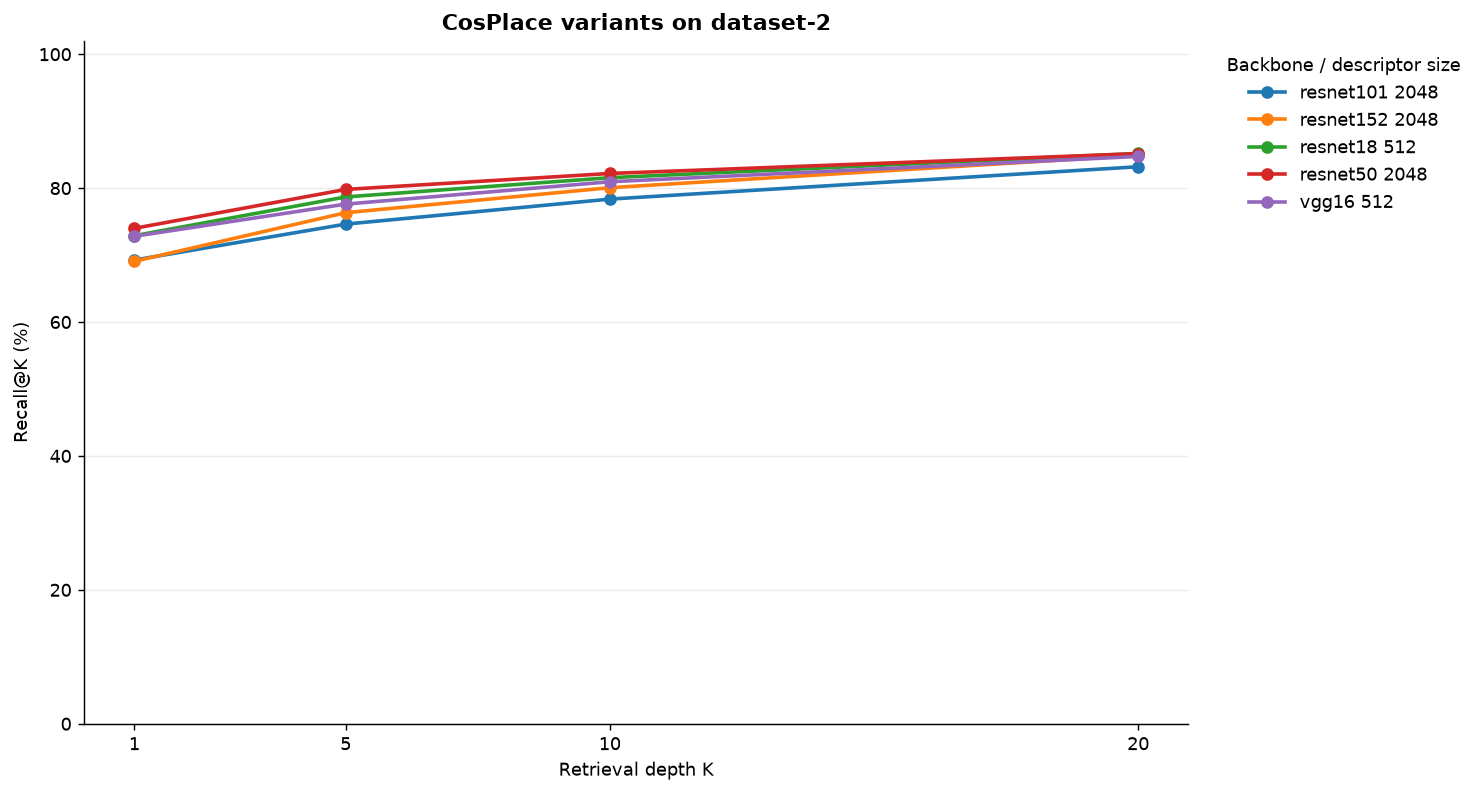

In [3]:
figure, axis = plt.subplots(figsize=(11.5, 6.2))
for color, path in zip(plt.cm.tab10(np.linspace(0, 1, max(10, len(SIMILARITY_FILES)))), SIMILARITY_FILES):
    axis.plot(TOP_K_VALUES, [100 * evaluations[path]['recall'][k] for k in TOP_K_VALUES], marker='o', linewidth=2, label=pretty_name(path), color=color)
axis.set(title='CosPlace variants on dataset-2', xlabel='Retrieval depth K', ylabel='Recall@K (%)', xticks=TOP_K_VALUES, ylim=(0, 102)); axis.grid(axis='y', alpha=.25)
axis.legend(title='Backbone / descriptor size', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False); figure.tight_layout()
figure.savefig(FIGURE_DIR / 'cosplace_recall_by_variant.pdf', bbox_inches='tight'); figure.savefig(FIGURE_DIR / 'cosplace_recall_by_variant.png', bbox_inches='tight', dpi=300); plt.show()

## 2. Label-wise Recall@1 and top-1 confusion matrix

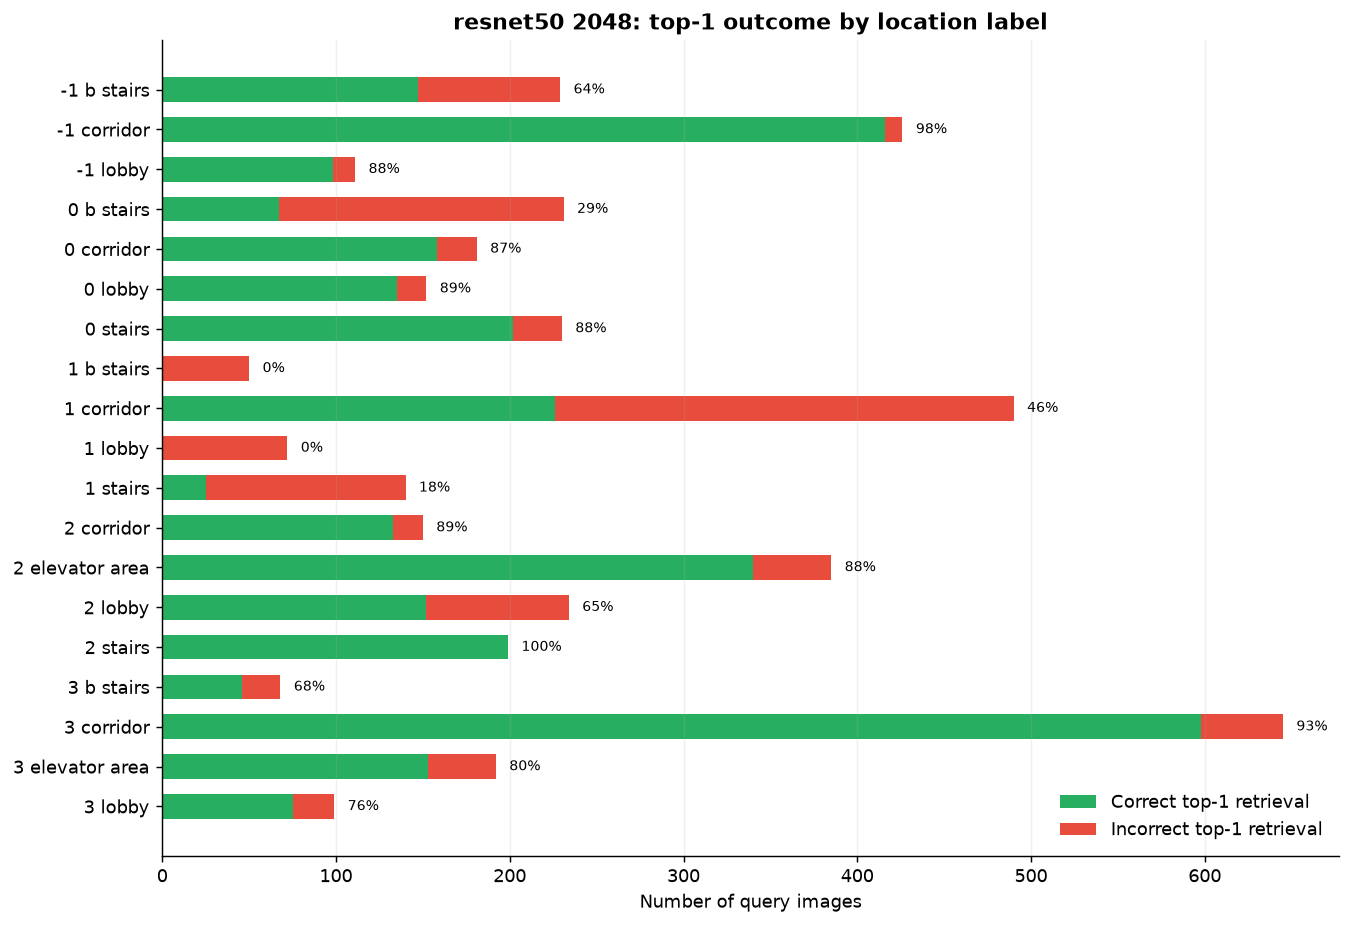

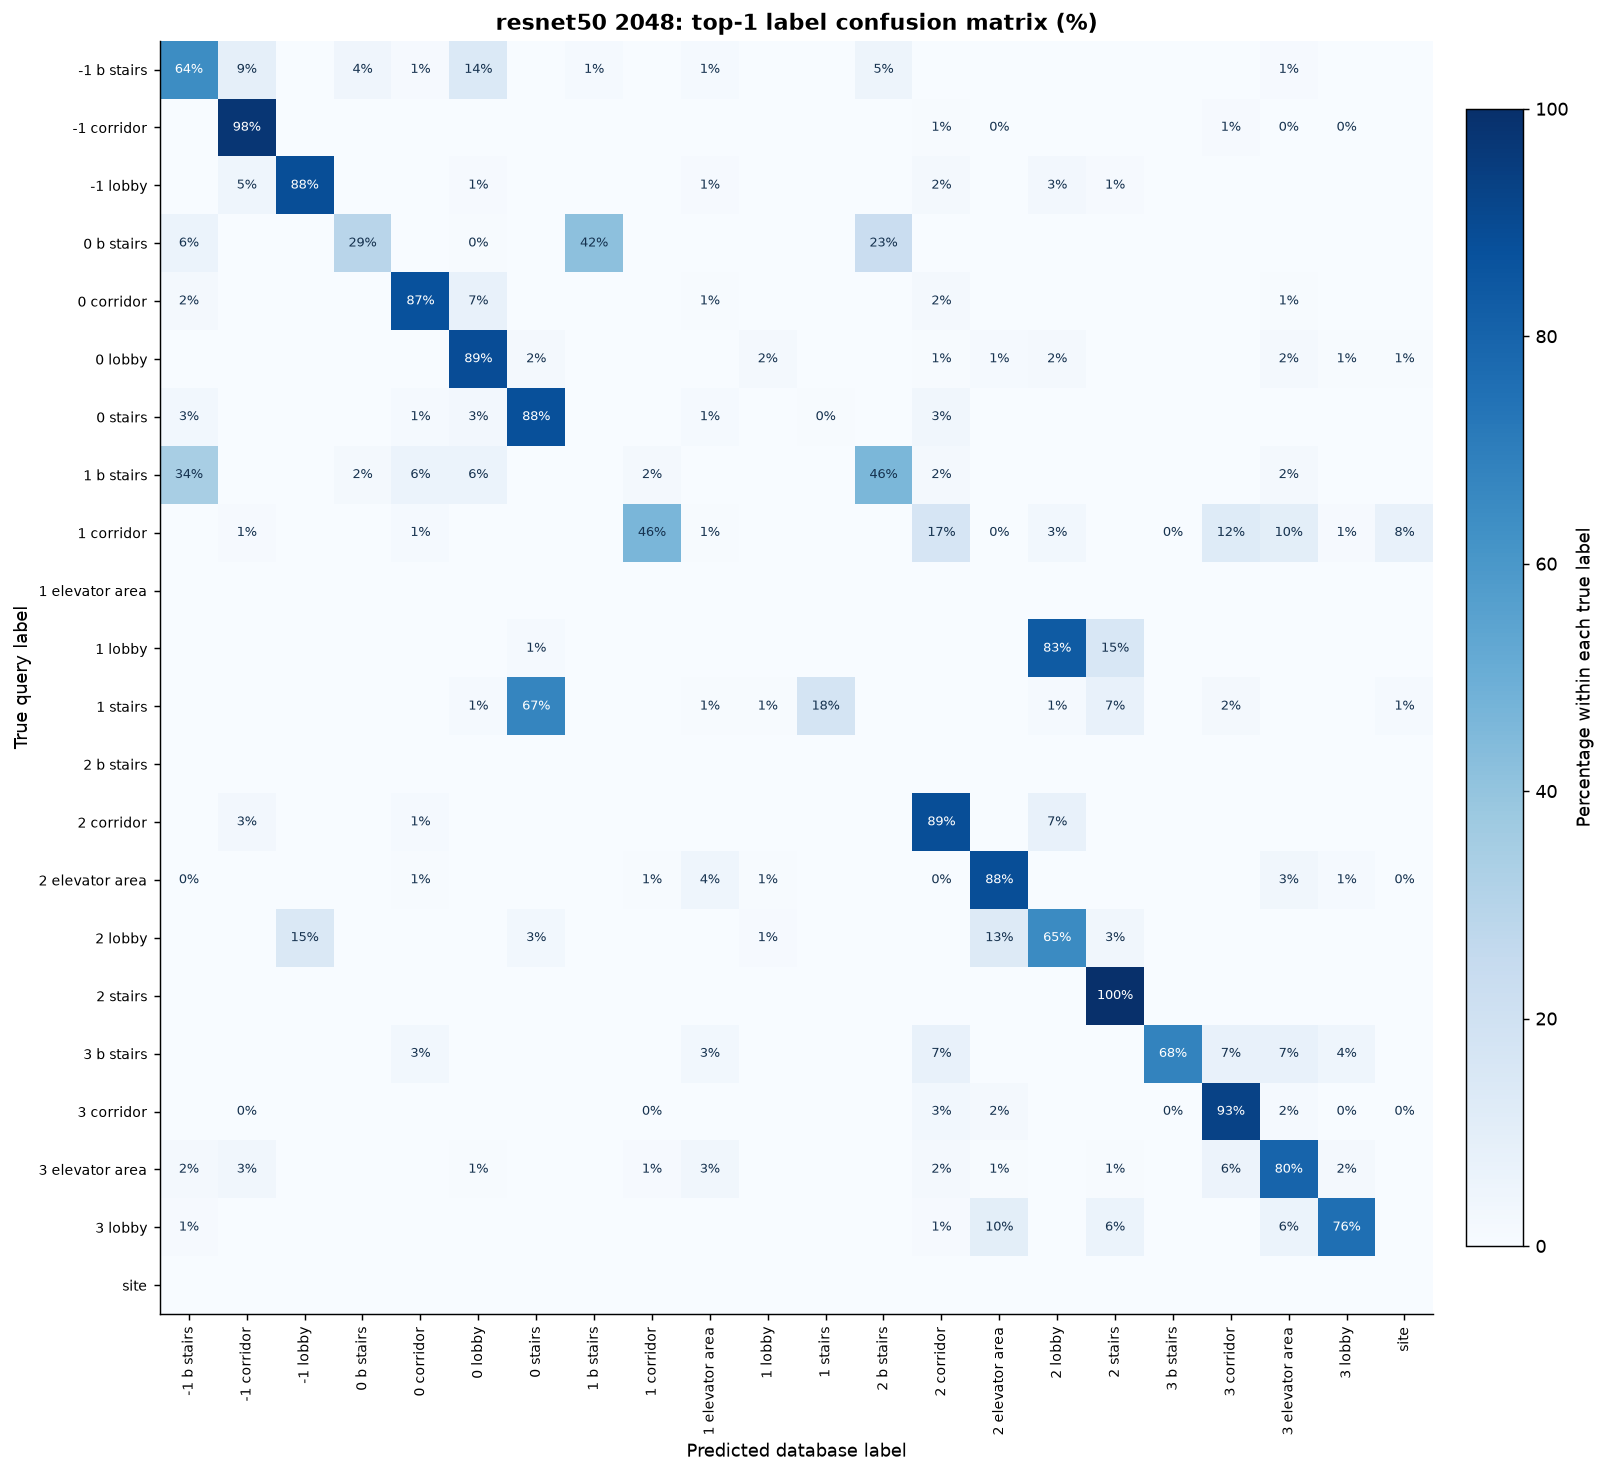

In [4]:
labels = sorted(best['count_by_label']); correct = np.array([best['correct_by_label'][label] for label in labels]); total = np.array([best['count_by_label'][label] for label in labels])
figure, axis = plt.subplots(figsize=(10.5, max(5.5, .38 * len(labels)))); y = np.arange(len(labels))
axis.barh(y, correct, color='#27ae60', height=.62, label='Correct top-1 retrieval'); axis.barh(y, total-correct, left=correct, color='#e74c3c', height=.62, label='Incorrect top-1 retrieval')
for yi, hit, n in zip(y, correct, total): axis.text(n + max(total)*.012, yi, f'{hit/n:.0%}', va='center', fontsize=8)
axis.set(yticks=y, yticklabels=labels, xlabel='Number of query images', title=f"{pretty_name(best_path)}: top-1 outcome by location label"); axis.invert_yaxis(); axis.grid(axis='x', alpha=.18); axis.legend(loc='lower right', frameon=False); figure.tight_layout()
figure.savefig(FIGURE_DIR / 'cosplace_best_label_recall_at_1.pdf', bbox_inches='tight'); figure.savefig(FIGURE_DIR / 'cosplace_best_label_recall_at_1.png', bbox_inches='tight', dpi=300); plt.show()

matrix_labels = sorted(set(best['count_by_label']) | {predicted for _, predicted in best['confusions']}); index = {label:i for i, label in enumerate(matrix_labels)}; matrix = np.zeros((len(matrix_labels), len(matrix_labels)))
for (true_label, predicted_label), count in best['confusions'].items(): matrix[index[true_label], index[predicted_label]] += count
percent = np.divide(matrix, matrix.sum(axis=1, keepdims=True), out=np.zeros_like(matrix), where=matrix.sum(axis=1, keepdims=True)>0) * 100
size = max(10, .52*len(matrix_labels)); figure, axis = plt.subplots(figsize=(size+2, size)); image = axis.imshow(percent, cmap='Blues', vmin=0, vmax=100)
for row in range(len(matrix_labels)):
    for column in range(len(matrix_labels)):
        if percent[row, column] > 0: axis.text(column, row, f"{percent[row, column]:.0f}%", ha='center', va='center', fontsize=7, color='white' if percent[row,column]>=55 else '#16324f')
axis.set(xticks=range(len(matrix_labels)), xticklabels=matrix_labels, yticks=range(len(matrix_labels)), yticklabels=matrix_labels, xlabel='Predicted database label', ylabel='True query label', title=f"{pretty_name(best_path)}: top-1 label confusion matrix (%)"); axis.tick_params(axis='x', labelrotation=90, labelsize=8); axis.tick_params(axis='y', labelsize=8); figure.colorbar(image, ax=axis, fraction=.035, pad=.02, label='Percentage within each true label'); figure.tight_layout()
figure.savefig(FIGURE_DIR / 'cosplace_best_top1_confusion_matrix.pdf', bbox_inches='tight'); figure.savefig(FIGURE_DIR / 'cosplace_best_top1_confusion_matrix.png', bbox_inches='tight', dpi=300); plt.show()

## 3. Curated top-5 retrieval examples

Two rows have five correct matches; the third has exactly one incorrect match. Override `RETRIEVAL_EXAMPLE_INDICES` with three query indices if desired.

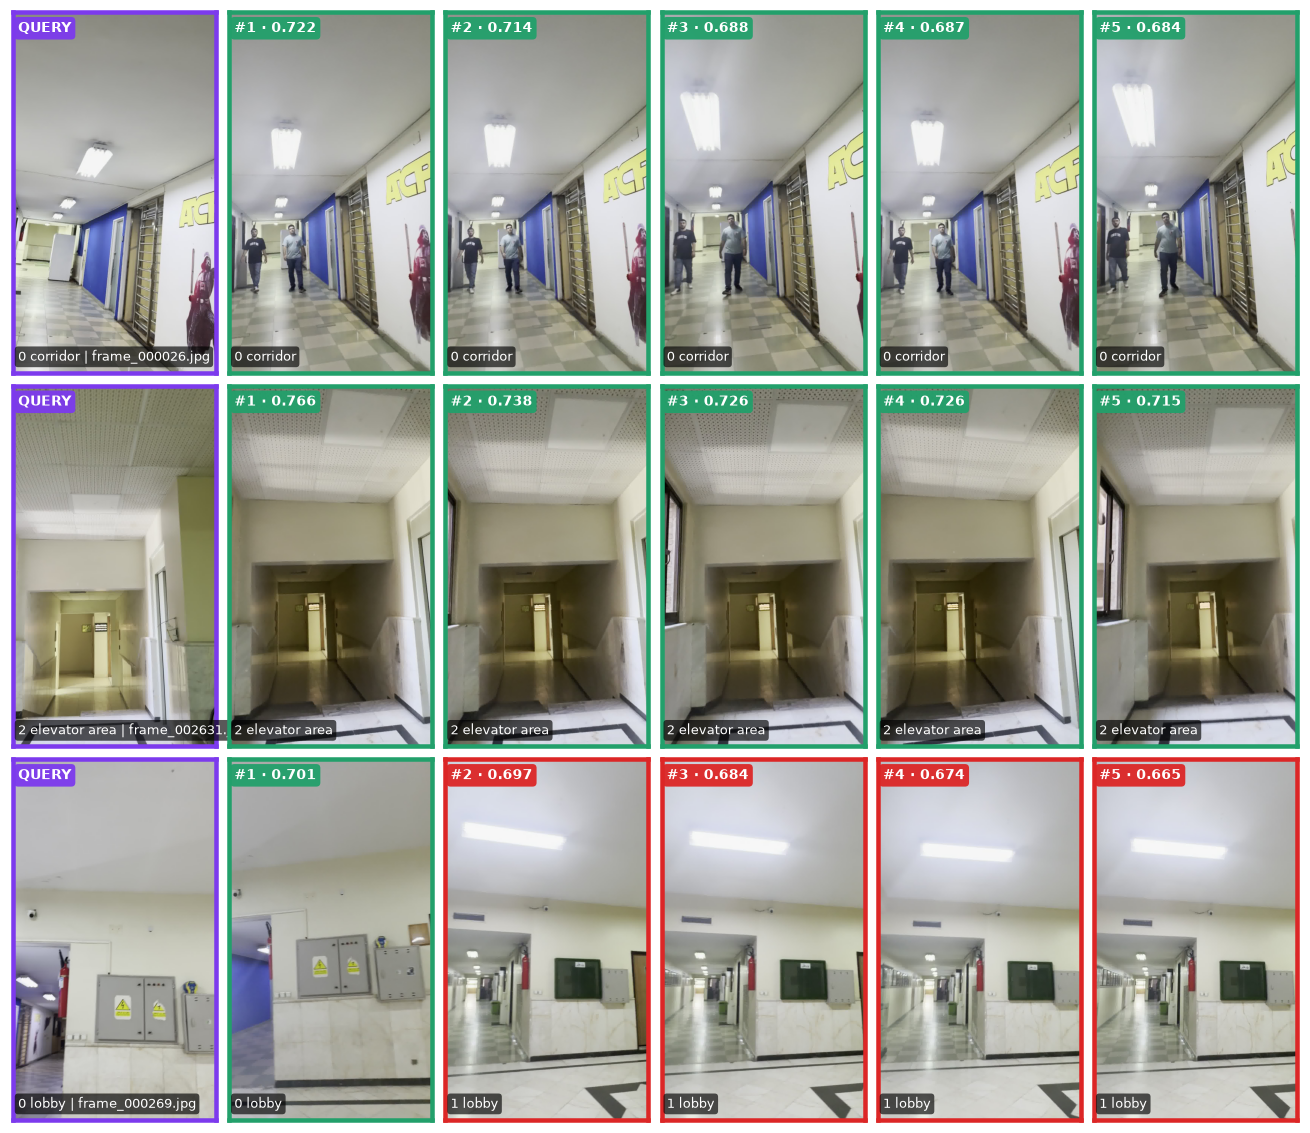

: 

In [ ]:
all_correct = [row for row in best['examples'] if row['top5_correct'].all()]; one_incorrect = [row for row in best['examples'] if row['top5_correct'].sum() == 1]
if len(all_correct) < 2 or not one_incorrect: raise RuntimeError('Could not find the requested top-5 example mix.')
retrieval_examples = [all_correct[10], all_correct[len(all_correct)//2 + 100], one_incorrect[7]]; RETRIEVAL_EXAMPLE_INDICES = None  # Example: [12, 319, 842]
if RETRIEVAL_EXAMPLE_INDICES is not None:
    by_index = {row['query_index']:row for row in best['examples']}; retrieval_examples = [by_index[index] for index in RETRIEVAL_EXAMPLE_INDICES]
if len(retrieval_examples) != 3: raise ValueError('Choose exactly three query indices.')

def card(axis, path, header, footer, color):
    with Image.open(path) as image: axis.imshow(image.convert('RGB'))
    axis.set_xticks([]); axis.set_yticks([])
    for spine in axis.spines.values(): spine.set_visible(True); spine.set_linewidth(2.5); spine.set_edgecolor(color)
    axis.text(.025,.975,header,transform=axis.transAxes,ha='left',va='top',color='white',fontsize=8,fontweight='bold',bbox={'boxstyle':'round,pad=.28','facecolor':color,'edgecolor':'none','alpha':.95})
    axis.text(.025,.025,footer,transform=axis.transAxes,ha='left',va='bottom',color='white',fontsize=7.3,bbox={'boxstyle':'round,pad=.25','facecolor':'#000000','edgecolor':'none','alpha':.65})

figure, axes = plt.subplots(3,6,figsize=(10,9),facecolor='white',gridspec_kw={'hspace':.035,'wspace':0})
for row_number, row in enumerate(retrieval_examples):
    card(axes[row_number,0],row['query_path'],'QUERY',f"{row['query_label']} | {row['query_path'].name}",'#7C3AED')
    for rank,(database_index,score,is_correct) in enumerate(zip(row['top5_indices'],row['top5_scores'],row['top5_correct']),start=1):
        path=database_paths[int(database_index)]; card(axes[row_number,rank],path,f'#{rank} · {score:.3f}',database_label_by_name[path.name],'#22a06b' if is_correct else '#dc2626')
figure.subplots_adjust(left=.001,right=.999,bottom=.008,top=.955,hspace=.035,wspace=0)
figure.savefig(FIGURE_DIR / 'cosplace_best_top5_retrieval_examples.pdf', bbox_inches='tight', facecolor='white'); figure.savefig(FIGURE_DIR / 'cosplace_best_top5_retrieval_examples.png', bbox_inches='tight', dpi=300, facecolor='white'); plt.show()

## 4. CosPlace occlusion sensitivity

The top row is the exact input sent to CosPlace. The standalone lower heatmap uses dark blue for small descriptor changes and dark red for large changes.

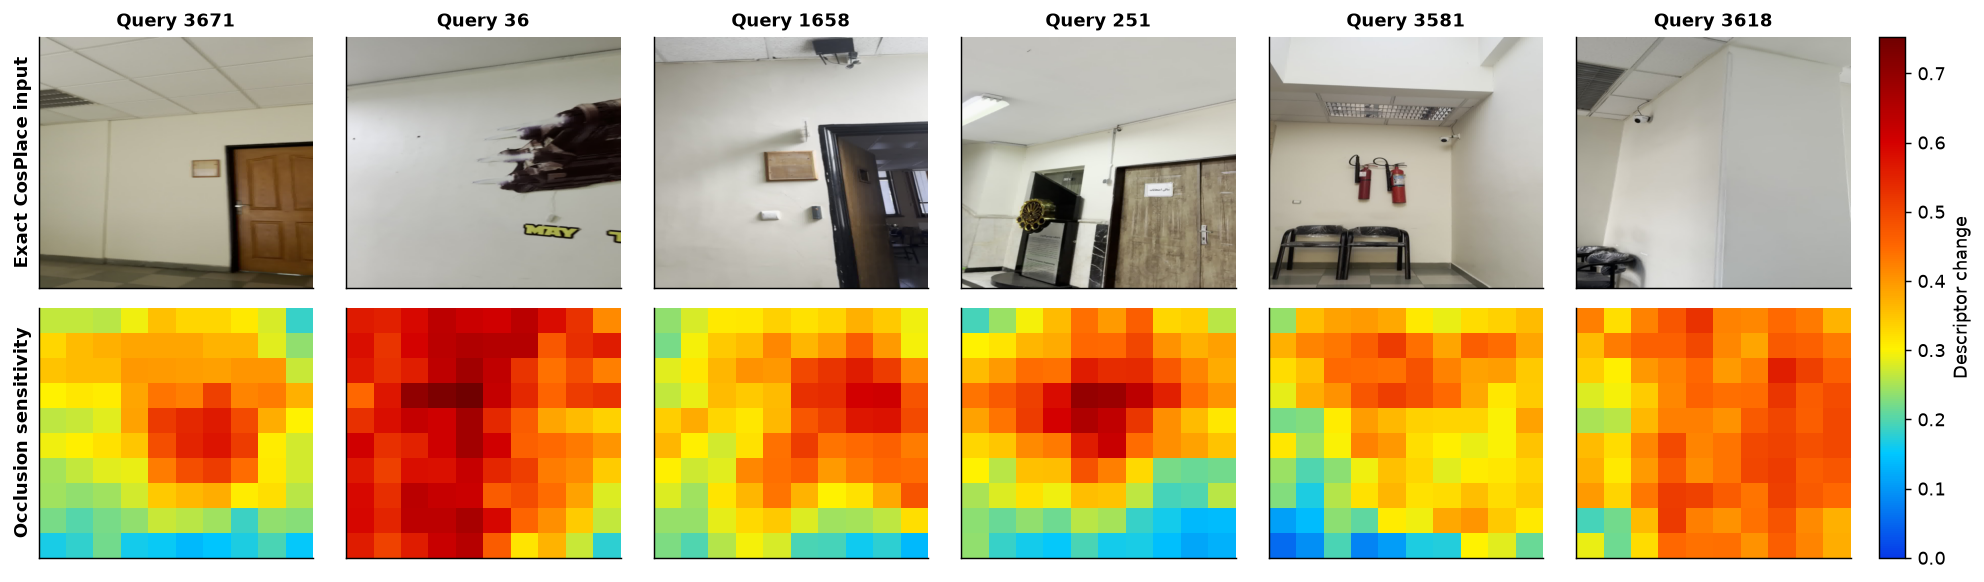

In [15]:
import indoor_vpr.algorithms.cosplace as cosplace_module
importlib.reload(cosplace_module)
from indoor_vpr import create_algorithm

OCCLUSION_QUERY_INDICES = [3671, 36, 1658, 251, 3581, 3618]; OCCLUSION_GRID = 10; OCCLUDER_FRACTION = .22
def cosplace_options(path):
    backbone, output_dim = path.stem.removeprefix('_cosplace_').removesuffix('_similarity').rsplit('_', 1)
    backbone = {'vgg16':'VGG16', 'resnet18':'ResNet18', 'resnet50':'ResNet50', 'resnet101':'ResNet101', 'resnet152':'ResNet152'}[backbone]
    return {'backbone':backbone, 'fc_output_dim':int(output_dim), 'image_size':512, 'batch_size':8}
algorithm = create_algorithm('cosplace', **cosplace_options(best_path))
def model_input(path):
    with Image.open(path) as source: tensor=algorithm.transform(source.convert('RGB'))
    mean=algorithm.torch.tensor([.485,.456,.406])[:,None,None]; std=algorithm.torch.tensor([.229,.224,.225])[:,None,None]
    return tensor.to(algorithm.device), (tensor.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()
def encode(tensor):
    with algorithm.torch.inference_mode(): return algorithm.model(tensor.unsqueeze(0)).squeeze(0).cpu().numpy()
def sensitivity(path):
    tensor,rgb=model_input(path); height,width=tensor.shape[-2:]; patch=max(16,round(min(width,height)*OCCLUDER_FRACTION)); baseline=encode(tensor); gray=algorithm.torch.tensor([(0.5-.485)/.229,(0.5-.456)/.224,(0.5-.406)/.225],device=algorithm.device)[:,None,None]; heatmap=np.zeros((OCCLUSION_GRID,OCCLUSION_GRID))
    for row in range(OCCLUSION_GRID):
        for column in range(OCCLUSION_GRID):
            x=round(column*(width-patch)/max(1,OCCLUSION_GRID-1)); y=round(row*(height-patch)/max(1,OCCLUSION_GRID-1)); occluded=tensor.clone(); occluded[:,y:y+patch,x:x+patch]=gray; heatmap[row,column]=np.linalg.norm(baseline-encode(occluded))
    return rgb,heatmap
results=[sensitivity(query_paths[index]) for index in OCCLUSION_QUERY_INDICES]; maximum=max(heatmap.max() for _,heatmap in results)
input_dir=FIGURE_DIR/'occlusion_model_inputs'; input_dir.mkdir(exist_ok=True)
for index,(rgb,_) in zip(OCCLUSION_QUERY_INDICES,results): Image.fromarray((rgb*255).round().astype(np.uint8)).save(input_dir/f'query_{index:04d}_cosplace_input.png')
cmap=LinearSegmentedColormap.from_list('sensitivity',['#0739e8','#00c8ff','#fff200','#ff6700','#d40000','#700000'])
figure,axes=plt.subplots(2,len(results),figsize=(3.1*len(results),5.2),gridspec_kw={'hspace':.08,'wspace':.12})
for column,(rgb,heatmap) in enumerate(results):
    height,width=rgb.shape[:2]; axes[0,column].imshow(rgb,aspect='auto'); axes[0,column].set_title(f'Query {OCCLUSION_QUERY_INDICES[column]}',fontsize=10); heatmap_image=axes[1,column].imshow(heatmap,cmap=cmap,vmin=0,vmax=maximum,interpolation='nearest',extent=(0,width,height,0),aspect='auto')
    for axis in axes[:,column]: axis.set_xticks([]); axis.set_yticks([]); axis.set_aspect('auto')
axes[0,0].set_ylabel('Exact CosPlace input',fontweight='bold'); axes[1,0].set_ylabel('Occlusion sensitivity',fontweight='bold'); figure.colorbar(heatmap_image,ax=axes.ravel().tolist(),fraction=.018,pad=.015,label='Descriptor change'); figure.savefig(FIGURE_DIR/'cosplace_occlusion_sensitivity.pdf',bbox_inches='tight'); figure.savefig(FIGURE_DIR/'cosplace_occlusion_sensitivity.png',bbox_inches='tight',dpi=300); plt.show()